# Childcare Affordability Across U.S. Counties  
### Final Project Visual Analysis  

Shaghayegh Malekshahi  
DSC640-T301 Data Presentation & Visualization     
Bellevue University  

This notebook generates the visualizations used in the final presentation of the childcare affordability analysis. The goal is to examine patterns in childcare pricing and evaluate affordability across U.S. counties using the National Database of Childcare Prices.

In [2]:
# NDCP Final Project Charts

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dataset

This analysis uses the **National Database of Childcare Prices**, a county-level dataset published by the U.S. Department of Labor Women’s Bureau.

The dataset contains estimates of childcare prices across the United States and includes multiple childcare types and age groups.

Key variables used in this analysis include:

- Weekly childcare prices for **infants, toddlers, and preschool children**
- Prices for **center-based childcare and family childcare providers**
- **Median household income** by county

For clarity and consistency, the analysis focuses on **2018**, the most recent year available in the original dataset used for this project.

In [5]:
# 1) Load data

DATA_PATH = r"C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\project\Milestone 5\nationaldatabaseofchildcareprices.xlsx"
OUT_DIR = "final_charts"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print("Columns (sample):", df.columns[:30].tolist())


Shape: (34567, 227)
Columns (sample): ['State_Name', 'State_Abbreviation', 'County_Name', 'County_FIPS_Code', 'StudyYear', 'UNR_16', 'FUNR_16', 'MUNR_16', 'UNR_20to64', 'FUNR_20to64', 'MUNR_20to64', 'FLFPR_20to64', 'FLFPR_20to64_Under6', 'FLFPR_20to64_6to17', 'FLFPR_20to64_Under6_6to17', 'MLFPR_20to64', 'PR_F', 'PR_P', 'MHI', 'ME', 'FME', 'MME', 'MHI_2018', 'ME_2018', 'FME_2018', 'MME_2018', 'TotalPop', 'OneRace', 'OneRace_W', 'OneRace_B']


## Data Preparation

The dataset was filtered to include only records from **2018** in order to maintain consistency in the affordability calculations.

The following data preparation steps were performed:

- Selected variables relevant to childcare prices and household income
- Removed missing values in key variables
- Removed non-positive values for income and childcare prices
- Ensured numerical data types for calculations

These steps ensure that affordability metrics are calculated using valid and consistent records.

In [6]:
# 2) Helper utilities

def safe_col(df_, candidates):
    """Return the first column that exists from candidates; raise error if none."""
    for c in candidates:
        if c in df_.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)

In [10]:
# 3) Select/standardize key columns

# Year column can vary by dataset version. Try common options.
YEAR_COL = safe_col(df, ["StudyYear", "studyyear", "year", "Year"])

# Geography columns: State name or abbreviation varies.
STATE_COL = "State_Name"

# Median household income for 2018 often called MHI_2018 (or similar).
INCOME_COL = safe_col(df, ["MHI_2018", "mhi_2018", "MedianHouseholdIncome_2018", "MHI"])

# Childcare weekly median costs (center / family) by age group.
MC_INF = safe_col(df, ["MCInfant", "mc_infant", "MC_Infant"])
MC_TOD = safe_col(df, ["MCToddler", "mc_toddler", "MC_Toddler"])
MC_PRE = safe_col(df, ["MCPreschool", "mc_preschool", "MC_Preschool"])

MF_INF = safe_col(df, ["MFCCInfant", "mfcc_infant", "MFCC_Infant"])
MF_TOD = safe_col(df, ["MFCCToddler", "mfcc_toddler", "MFCC_Toddler"])
MF_PRE = safe_col(df, ["MFCCPreschool", "mfcc_preschool", "MFCC_Preschool"])

# Optional county name (nice for debugging; not required)
COUNTY_COL = None
for cand in ["CountyName", "county_name", "County", "COUNTY"]:
    if cand in df.columns:
        COUNTY_COL = cand
        break

## Derived Metrics

To evaluate childcare affordability, several additional measures were created:

**Annual Infant Childcare Cost**

Weekly infant childcare prices were converted to annual estimates:

Annual Infant Cost = Weekly Infant Cost × 52

**Affordability Ratio**

Affordability was measured as:

Annual Infant Childcare Cost / Median Household Income

This ratio represents the share of household income required to pay for infant childcare.

In [12]:
# 4) Filter to 2018 and clean

df18 = df.copy()
df18 = df18[df18[YEAR_COL] == 2018]

needed = [STATE_COL, INCOME_COL, MC_INF, MC_TOD, MC_PRE, MF_INF, MF_TOD, MF_PRE]
df18 = df18[needed + ([COUNTY_COL] if COUNTY_COL else [])].copy()

# Keep only valid records for affordability / comparisons
for c in [INCOME_COL, MC_INF, MF_INF, MC_TOD, MF_TOD, MC_PRE, MF_PRE]:
    df18[c] = pd.to_numeric(df18[c], errors="coerce")

df18 = df18.dropna(subset=[STATE_COL, INCOME_COL, MC_INF, MF_INF])
df18 = df18[(df18[INCOME_COL] > 0) & (df18[MC_INF] > 0) & (df18[MF_INF] > 0)]

print("2018 filtered shape:", df18.shape)

# Derived fields
df18["AnnualInfantCost_Center"] = df18[MC_INF] * 52
df18["AffordabilityRatio"] = df18["AnnualInfantCost_Center"] / df18[INCOME_COL]
df18["InfantGap_CenterMinusFamily"] = df18[MC_INF] - df18[MF_INF]

2018 filtered shape: (2340, 8)


## Visualization 1 — Childcare Costs by Age Group

This chart compares the average weekly childcare cost across three age groups: infants, toddlers, and preschool children.

The comparison also distinguishes between **center-based childcare providers** and **family childcare providers**.

The visualization highlights that infant childcare consistently represents the most expensive age group and that center-based childcare tends to cost more than family childcare.

Saved: final_charts\01_costs_by_age_center_vs_family.png


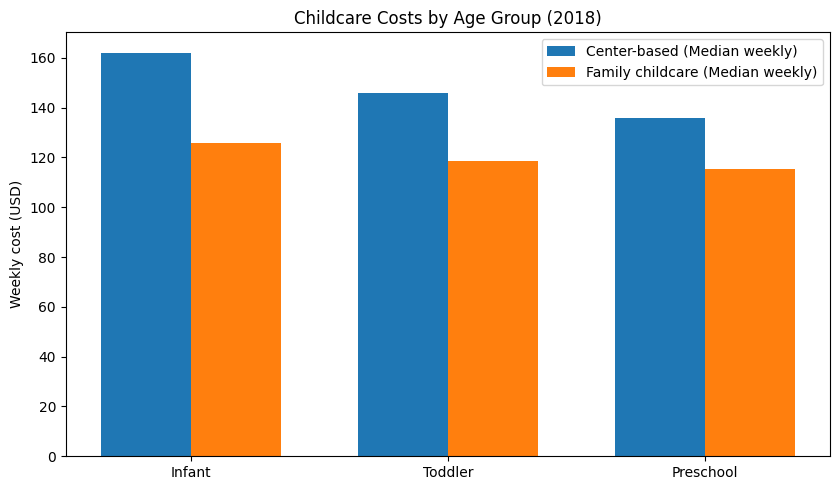

In [13]:
# 5) Chart 1: Costs by age group (Center vs Family)

age_groups = ["Infant", "Toddler", "Preschool"]
center_means = [
    df18[MC_INF].mean(),
    df18[MC_TOD].dropna().mean(),
    df18[MC_PRE].dropna().mean(),
]
family_means = [
    df18[MF_INF].mean(),
    df18[MF_TOD].dropna().mean(),
    df18[MF_PRE].dropna().mean(),
]

x = np.arange(len(age_groups))
width = 0.35

plt.figure(figsize=(8.5, 5))
plt.bar(x - width/2, center_means, width, label="Center-based (Median weekly)")
plt.bar(x + width/2, family_means, width, label="Family childcare (Median weekly)")
plt.xticks(x, age_groups)
plt.ylabel("Weekly cost (USD)")
plt.title("Childcare Costs by Age Group (2018)")
plt.legend()
savefig("01_costs_by_age_center_vs_family.png")
plt.show()

## Visualization 2 — Affordability Burden Distribution

This histogram shows the distribution of childcare affordability across counties.

Affordability is calculated as the ratio of annual infant childcare cost to median household income.

The distribution demonstrates that childcare affordability varies widely across counties, indicating that childcare cost burdens are not evenly distributed across the United States.

Saved: final_charts\02_affordability_ratio_hist.png


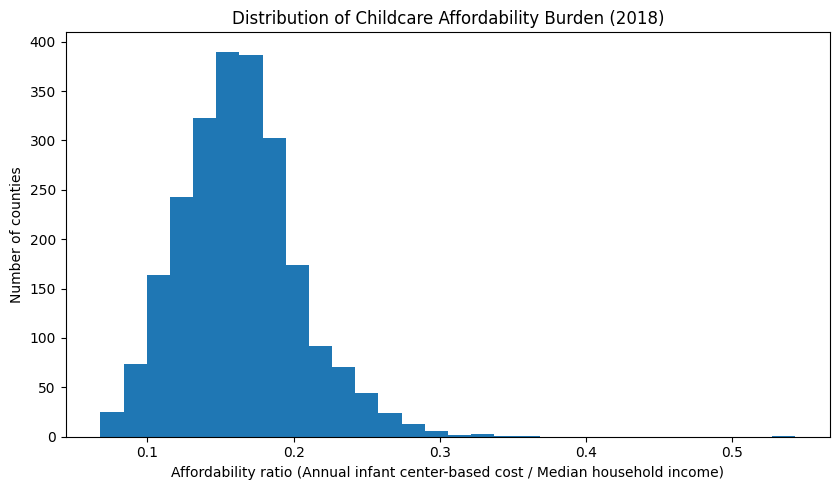

In [15]:
# 6) Chart 2: Affordability ratio distribution

plt.figure(figsize=(8.5, 5))
vals = df18["AffordabilityRatio"].replace([np.inf, -np.inf], np.nan).dropna()
plt.hist(vals, bins=30)
plt.xlabel("Affordability ratio (Annual infant center-based cost / Median household income)")
plt.ylabel("Number of counties")
plt.title("Distribution of Childcare Affordability Burden (2018)")
savefig("02_affordability_ratio_hist.png")
plt.show()

## Visualization 3 — States with the Highest Affordability Burden

This chart identifies the states with the highest average childcare affordability burden based on county-level data.

The results highlight geographic concentrations of childcare affordability challenges, suggesting that policy responses may need to be targeted toward specific regions.

Saved: final_charts\03_top10_states_affordability.png


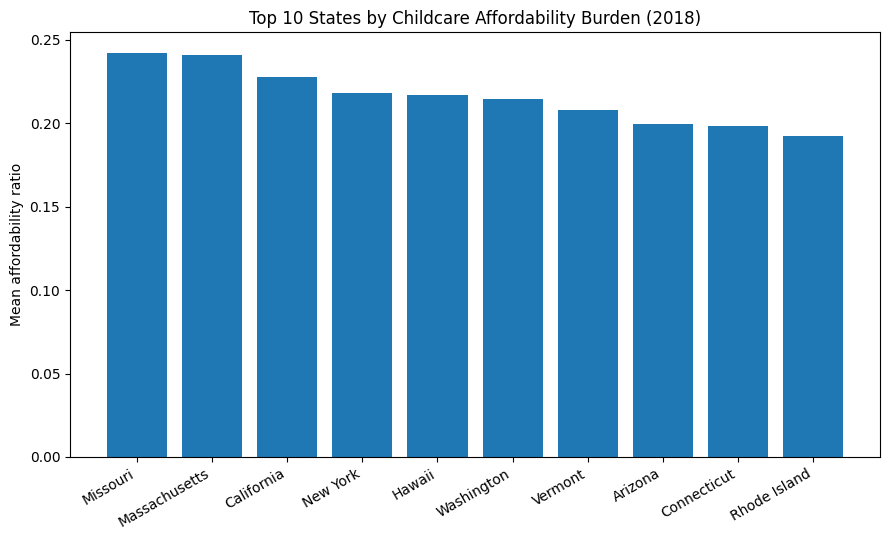

In [16]:
# 7) Chart 3: Top 10 states by affordability burden (mean ratio)

state_burden = (
    df18.groupby(STATE_COL, as_index=False)["AffordabilityRatio"]
    .mean()
    .sort_values("AffordabilityRatio", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5.5))
plt.bar(state_burden[STATE_COL].astype(str), state_burden["AffordabilityRatio"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean affordability ratio")
plt.title("Top 10 States by Childcare Affordability Burden (2018)")
savefig("03_top10_states_affordability.png")
plt.show()

## Visualization 4 — Income vs Childcare Cost Relationship

This scatter plot examines the relationship between median household income and weekly infant childcare cost.

The visualization demonstrates that higher income does not always correspond to lower childcare costs, indicating that structural pricing differences across regions influence affordability.

Saved: final_charts\04_income_vs_infant_cost_scatter.png


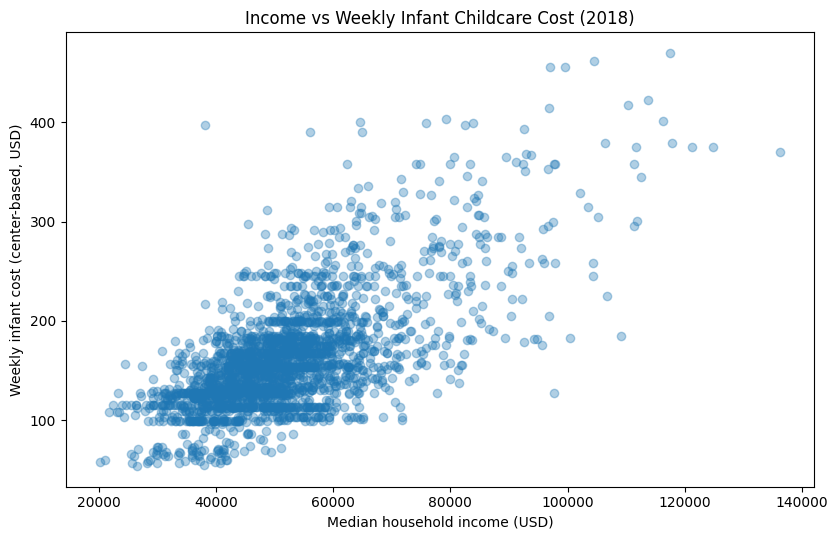

In [17]:
# 8) Chart 4: Income vs infant cost scatter

plt.figure(figsize=(8.5, 5.5))
plt.scatter(df18[INCOME_COL], df18[MC_INF], alpha=0.35)
plt.xlabel("Median household income (USD)")
plt.ylabel("Weekly infant cost (center-based, USD)")
plt.title("Income vs Weekly Infant Childcare Cost (2018)")
savefig("04_income_vs_infant_cost_scatter.png")
plt.show()

## Visualization 5 — Center vs Family Infant Care Cost Gap

This chart illustrates the difference between center-based infant childcare costs and family childcare costs.

The results show that family childcare often represents a lower-cost alternative in many counties, although the gap between provider types varies across regions.

Saved: final_charts\05_center_vs_family_infant_gap_hist.png


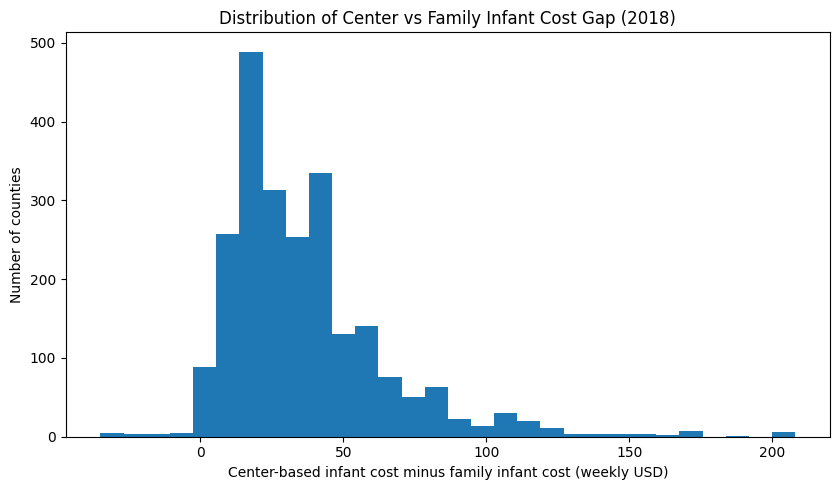

In [18]:
# 9) Chart 5: Center vs family infant cost gap (distribution)

plt.figure(figsize=(8.5, 5))
gap = df18["InfantGap_CenterMinusFamily"].dropna()
plt.hist(gap, bins=30)
plt.xlabel("Center-based infant cost minus family infant cost (weekly USD)")
plt.ylabel("Number of counties")
plt.title("Distribution of Center vs Family Infant Cost Gap (2018)")
savefig("05_center_vs_family_infant_gap_hist.png")
plt.show()

## Dashboard Concept

An interactive dashboard would allow analysts and policymakers to explore childcare affordability patterns in greater detail.

Possible dashboard features include:

- Geographic filters by state or county
- Childcare type filters (center-based vs family childcare)
- Age group selection
- Affordability threshold comparisons

Such a dashboard would support deeper exploration of childcare affordability patterns and help identify high-burden regions.

Saved: final_charts\06_dashboard_mockup.png


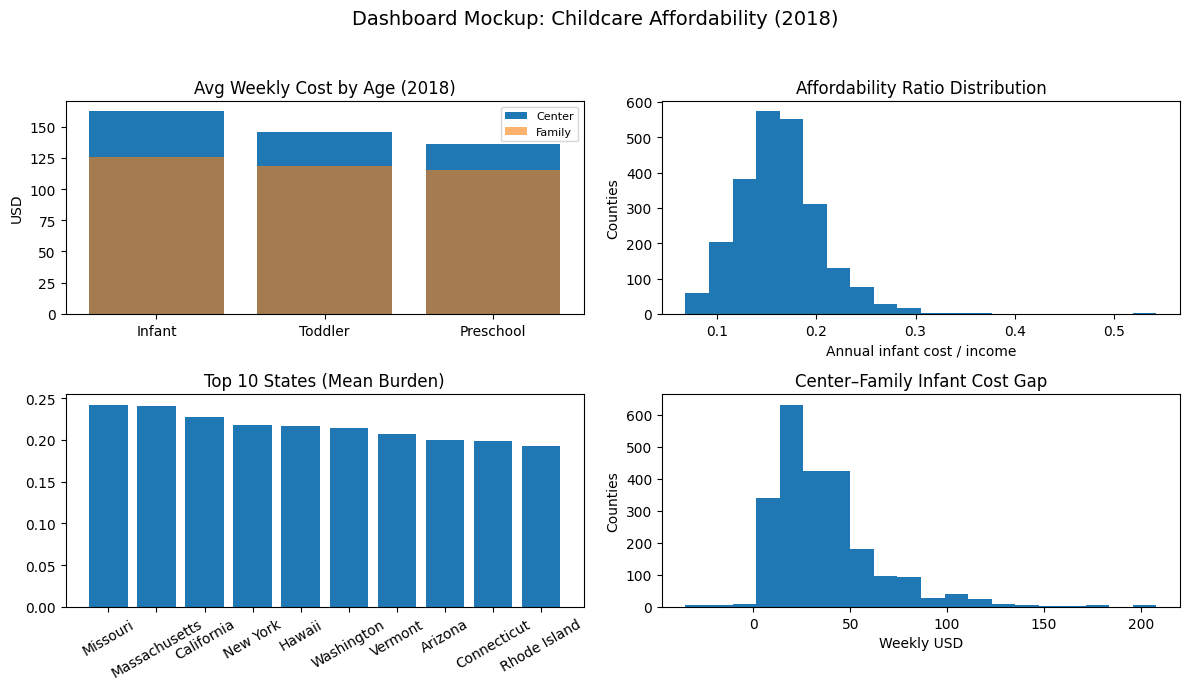

In [19]:
# 10) Dashboard mockup: one image combining key indicators (single figure)
#     (Still matplotlib-only; looks like a dashboard slide image)

fig = plt.figure(figsize=(12, 7))

# Top left: Costs by age group (mini)
ax1 = fig.add_subplot(2, 2, 1)
ax1.bar(age_groups, center_means, label="Center")
ax1.bar(age_groups, family_means, alpha=0.6, label="Family")
ax1.set_title("Avg Weekly Cost by Age (2018)")
ax1.set_ylabel("USD")
ax1.legend(fontsize=8)

# Top right: Affordability histogram (mini)
ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(vals, bins=20)
ax2.set_title("Affordability Ratio Distribution")
ax2.set_xlabel("Annual infant cost / income")
ax2.set_ylabel("Counties")

# Bottom left: Top states bar (mini)
ax3 = fig.add_subplot(2, 2, 3)
ax3.bar(state_burden[STATE_COL].astype(str), state_burden["AffordabilityRatio"])
ax3.set_title("Top 10 States (Mean Burden)")
ax3.tick_params(axis='x', rotation=30)

# Bottom right: Gap histogram (mini)
ax4 = fig.add_subplot(2, 2, 4)
ax4.hist(gap, bins=20)
ax4.set_title("Center–Family Infant Cost Gap")
ax4.set_xlabel("Weekly USD")
ax4.set_ylabel("Counties")

fig.suptitle("Dashboard Mockup: Childcare Affordability (2018)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
dash_path = os.path.join(OUT_DIR, "06_dashboard_mockup.png")
plt.savefig(dash_path, dpi=200, bbox_inches="tight")
print("Saved:", dash_path)
plt.show()

## Infographic Concept

The infographic medium is designed for parents, advocacy groups, and the general public.

The infographic simplifies the analysis by highlighting key insights such as:

- Average childcare costs
- Differences between childcare provider types
- The financial burden faced by families with infants

The goal is to communicate complex data insights in a clear and accessible format for a broader audience.

Saved: final_charts\07_infographic_snapshot.png


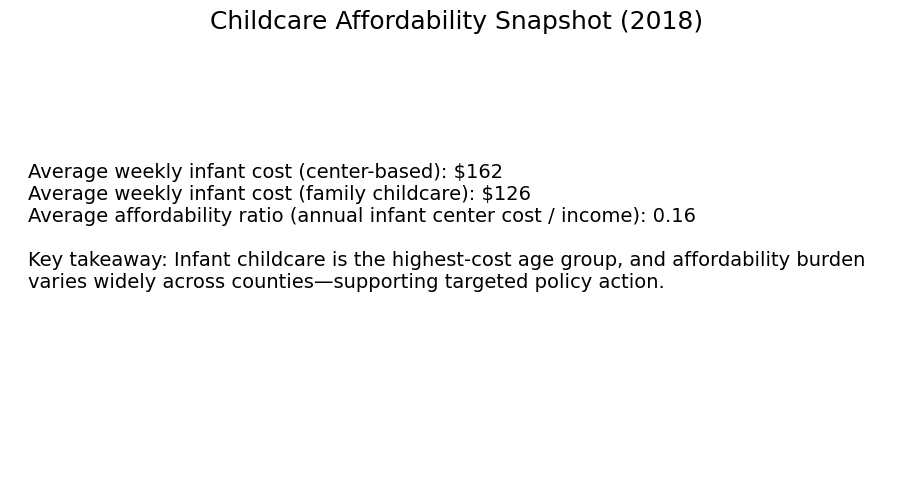


All charts saved in: C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\winter 2026\Data presentation\project\Milestone 5\final_charts
Files: ['01_costs_by_age_center_vs_family.png', '02_affordability_ratio_hist.png', '03_top10_states_affordability.png', '04_income_vs_infant_cost_scatter.png', '05_center_vs_family_infant_gap_hist.png', '06_dashboard_mockup.png', '07_infographic_snapshot.png']


In [20]:
# 11) Infographic-style single visual (simple, public-facing)

# Use 3 numbers: Avg weekly infant center, avg weekly infant family, avg affordability ratio
avg_infant_center = df18[MC_INF].mean()
avg_infant_family = df18[MF_INF].mean()
avg_ratio = df18["AffordabilityRatio"].mean()

plt.figure(figsize=(10, 5))
plt.axis("off")
plt.title("Childcare Affordability Snapshot (2018)", fontsize=18, pad=20)

txt = (
    f"Average weekly infant cost (center-based): ${avg_infant_center:,.0f}\n"
    f"Average weekly infant cost (family childcare): ${avg_infant_family:,.0f}\n"
    f"Average affordability ratio (annual infant center cost / income): {avg_ratio:.2f}\n\n"
    "Key takeaway: Infant childcare is the highest-cost age group, and affordability burden\n"
    "varies widely across counties—supporting targeted policy action."
)

plt.text(0.02, 0.75, txt, fontsize=14, va="top")
savefig("07_infographic_snapshot.png")
plt.show()

print("\nAll charts saved in:", os.path.abspath(OUT_DIR))
print("Files:", os.listdir(OUT_DIR))